In [1]:
from rpgpy import rpg2nc
import numpy as np
from gfatpy.radar.rpg_nc import rpg
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from gfatpy.radar.retrieve import retrieve
from gfatpy.radar.retrieve.retrieve import retrieve_KDP, retrieve_spec_KDP, spec_to_moments
from phd_clouds.utils import spherical_to_cartesian, convert_azimuth_y_to_x, cartesian_to_spherical,\
                             download_cloudnet_products, get_instrument_name
from IPython import get_ipython
from rpgpy import read_rpg
import xarray as xr
import glob
from matplotlib.colors import Normalize
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator
from mayavi import mlab
import glob

plt.close('all')

# mpl.use('qtagg')
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

# Joyrad-94

## Converting binary files to netcdf
### - LV0 files

In [2]:
raw_folder     = "/Users/matheussilva/Documents/data-joydurado/joydurado94/D21/"
product_folder = "/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/"

date    = "" # use this to specify a date only if data are inside a folder like this 2024/01/01
# pattern = "VITAL_SEC2*_14*RHI.LV1"
# pattern = "VITAL_SEC2*_12*RHI.LV1"
pattern = "VITAL*10*RHI.LV1"

# check if exist the folder raw folder first
if os.path.exists(raw_folder):
    raw_files = os.path.join(raw_folder, date) # folder with raw files
    print("path to raw files: ", raw_files)

    print("path to products files:", product_folder)

    print("make product folder if it does not exist ...")
    # make the folder if it does not exist
    os.makedirs(product_folder, exist_ok=True) 

    # get the list of raw files lv1
    filepaths = glob.glob(os.path.join(raw_files, pattern))
    
    print("converting files to netcdf if they do not exist ...")
    # check if there are files to process or if they already exist
    if len(filepaths) == 0 or all([os.path.exists(os.path.join(product_folder, f.split("/")[-1]+".nc")) for f in filepaths]):
        print("There are no files to process or they already exist")
    else:
        # converting to raw files to netcdf using rpgpy
        for f in filepaths:
            print("converting file:", f)
            rpg2nc(f, os.path.join(product_folder, f.split("/")[-1]+".nc"))

else:
    print("The raw folder does not exist")

# get filepath of files ended with RHI.LV1.nc
filepaths = glob.glob(os.path.join(product_folder, pattern+".nc"))

filepaths = [
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_100852_P08_RHI.LV1.nc',
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_101001_P08_RHI.LV1.nc',
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_101107_P08_RHI.LV1.nc',
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_101213_P08_RHI.LV1.nc',
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_101325_P08_RHI.LV1.nc',
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC3_240821_101549_P08_RHI.LV1.nc',
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC3_240821_101654_P08_RHI.LV1.nc',
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC3_240821_101800_P08_RHI.LV1.nc',
             '/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC3_240821_101910_P08_RHI.LV1.nc',
]

# order the files by date
filepaths = sorted(filepaths)

# check if there are files to process
if len(filepaths) == 0:
    print("There are no files to process")
else:
    print("netcdf files created by rpgpy:")
    for f in filepaths:
        print(f)

    # check if filepaths is a list:
    print("\nreading the file as radar class in gfatpy...")
    if isinstance(filepaths, list):
        radar = rpg(filepaths[0])
    else:
        radar = rpg(filepaths)

path to raw files:  /Users/matheussilva/Documents/data-joydurado/joydurado94/D21/
path to products files: /Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/
make product folder if it does not exist ...
converting files to netcdf if they do not exist ...
There are no files to process or they already exist
netcdf files created by rpgpy:
/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_100852_P08_RHI.LV1.nc
/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_101001_P08_RHI.LV1.nc
/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_101107_P08_RHI.LV1.nc
/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_101213_P08_RHI.LV1.nc
/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC2_240821_101325_P08_RHI.LV1.nc
/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/VITAL_SEC3_240821_10154

In [3]:
rpg_radar_list94 = [rpg(f) for f in filepaths]

In [ ]:
# Clouds detected with mira
# - 14:10
# - 12_30 12:50
# - 15:40

# Look at hamhat folder for eht lwp 

# Joyrad 34

## Converting binary files to netcdf
### - LV0 files

In [36]:
raw_folder     = "/Users/matheussilva/Documents/data-joydurado/joydurado35/D15/"
product_folder = "/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado35/D15/"


# check if exist the folder raw folder first
if os.path.exists(raw_folder):
    raw_files = os.path.join(raw_folder, date) # folder with raw files
    print("path to raw files: ", raw_files)

    print("path to products files:", product_folder)

    print("make product folder if it does not exist ...")
    # make the folder if it does not exist
    os.makedirs(product_folder, exist_ok=True) 

    # get the list of raw files lv1
    filepaths = glob.glob(os.path.join(raw_files, pattern))
    
    print("converting files to netcdf if they do not exist ...")
    # check if there are files to process or if they already exist
    if len(filepaths) == 0 or all([os.path.exists(os.path.join(product_folder, f.split("/")[-1]+".nc")) for f in filepaths]):
        print("There are no files to process or they already exist")
    else:
        # converting to raw files to netcdf using rpgpy
        for f in filepaths:
            print("converting file:", f)
            rpg2nc(f, os.path.join(product_folder, f.split("/")[-1]+".nc"))

else:
    print("The raw folder does not exist")

# get filepath of files ended with RHI.LV1.nc
filepaths = glob.glob(os.path.join(product_folder, pattern+".nc"))

# order the files by date
filepaths = sorted(filepaths)

# check if there are files to process
if len(filepaths) == 0:
    print("There are no files to process")
else:
    print("netcdf files created by rpgpy:")
    for f in filepaths:
        print(f)

    # check if filepaths is a list:
    print("\nreading the file as radar class in gfatpy...")
    if isinstance(filepaths, list):
        radar = rpg(filepaths[0])
    else:
        radar = rpg(filepaths)

rpg_radar_list35 = [rpg(f) for f in filepaths]


path to raw files:  /Users/matheussilva/Documents/data-joydurado/joydurado35/
path to products files: /Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado35/D15/
make product folder if it does not exist ...
converting files to netcdf if they do not exist ...
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado35/VITAL_SEC3_240815_111630_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado35/VITAL_SEC1_240815_111957_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado35/VITAL_SEC3_240815_111052_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado35/VITAL_SEC3_240815_111421_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado35/VITAL_SEC3_240815_111206_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado35/VITAL_SEC3_240815_111524_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/jo

/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates

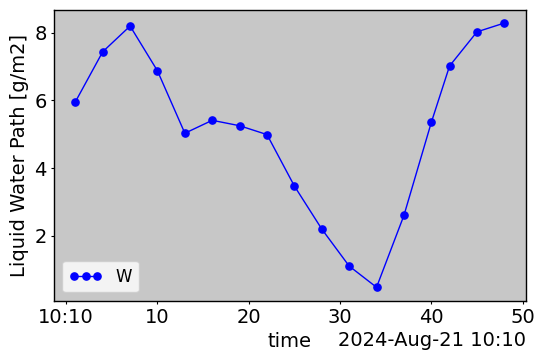

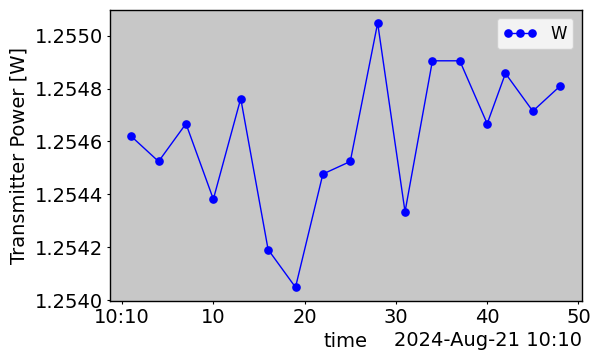

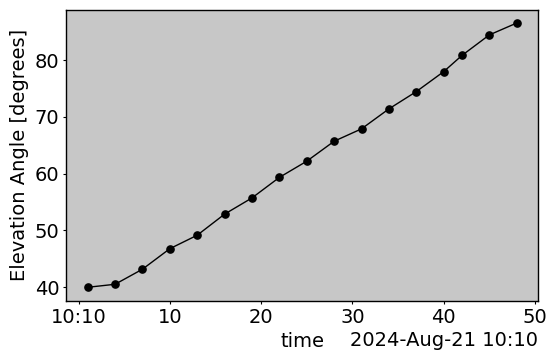

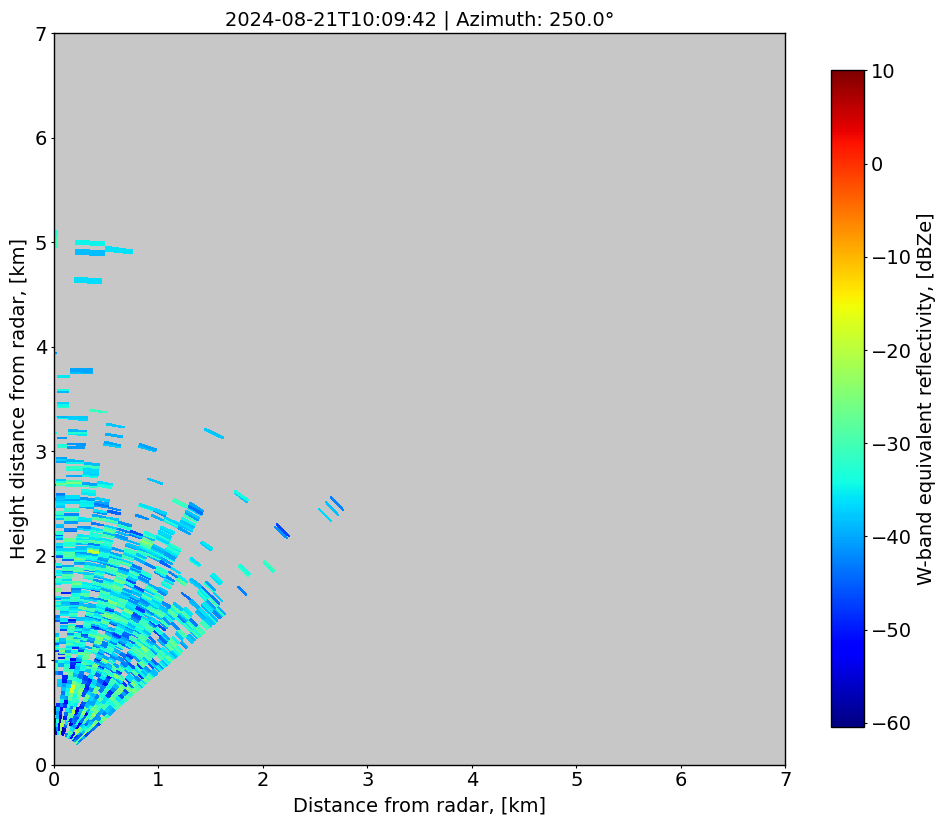

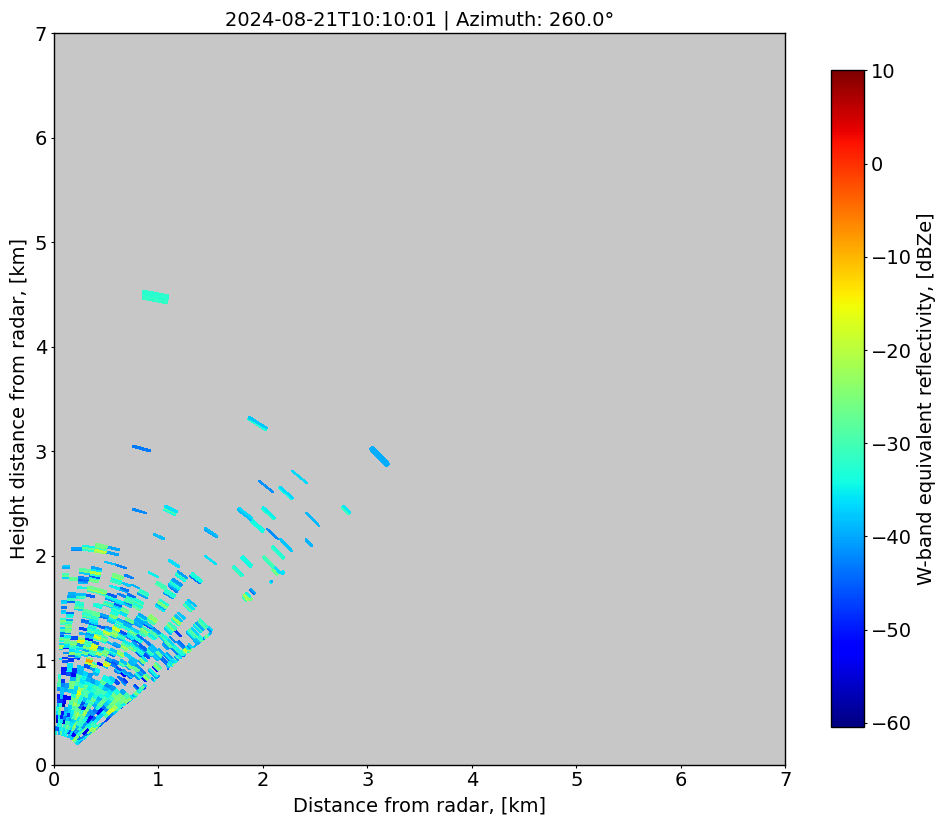

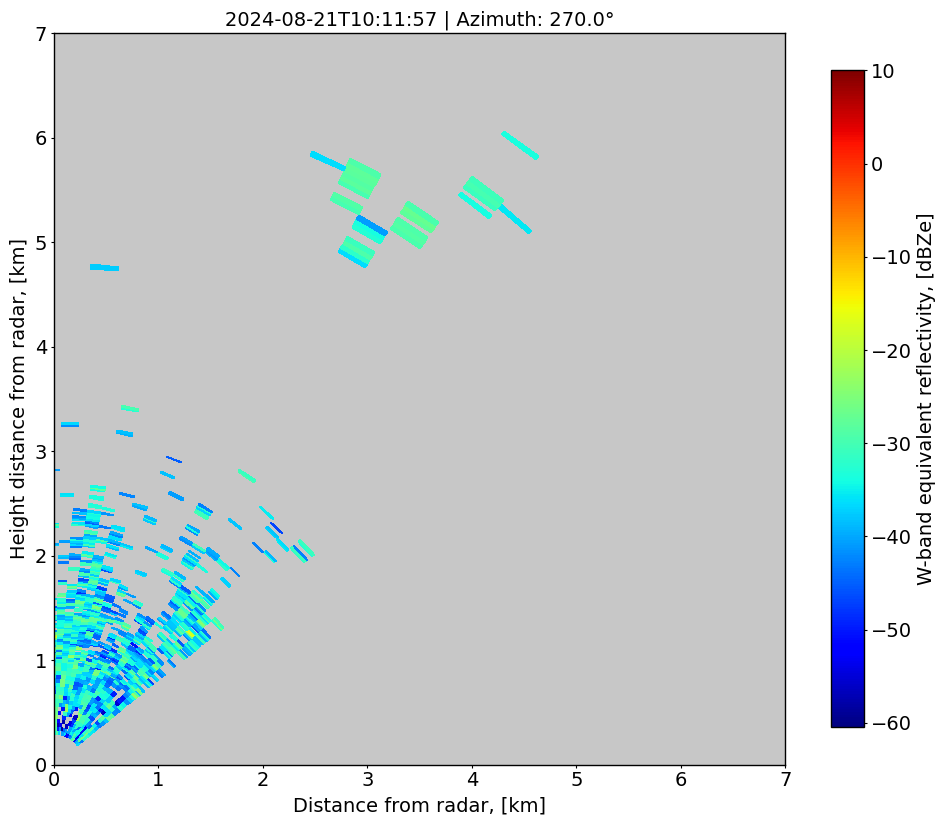

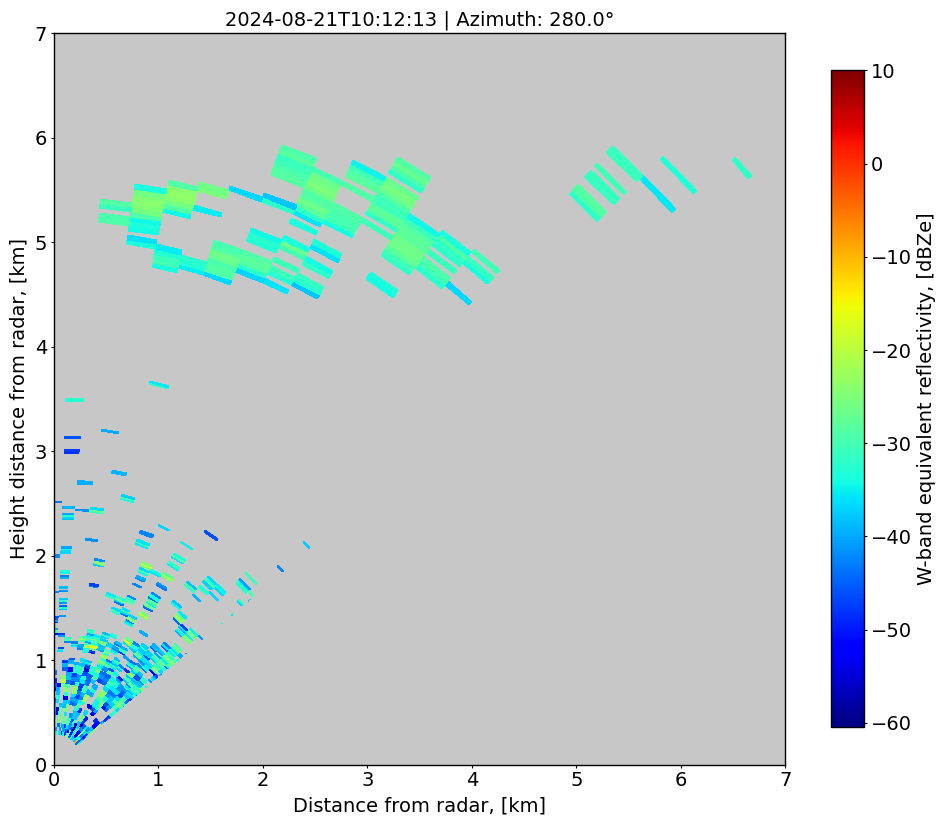

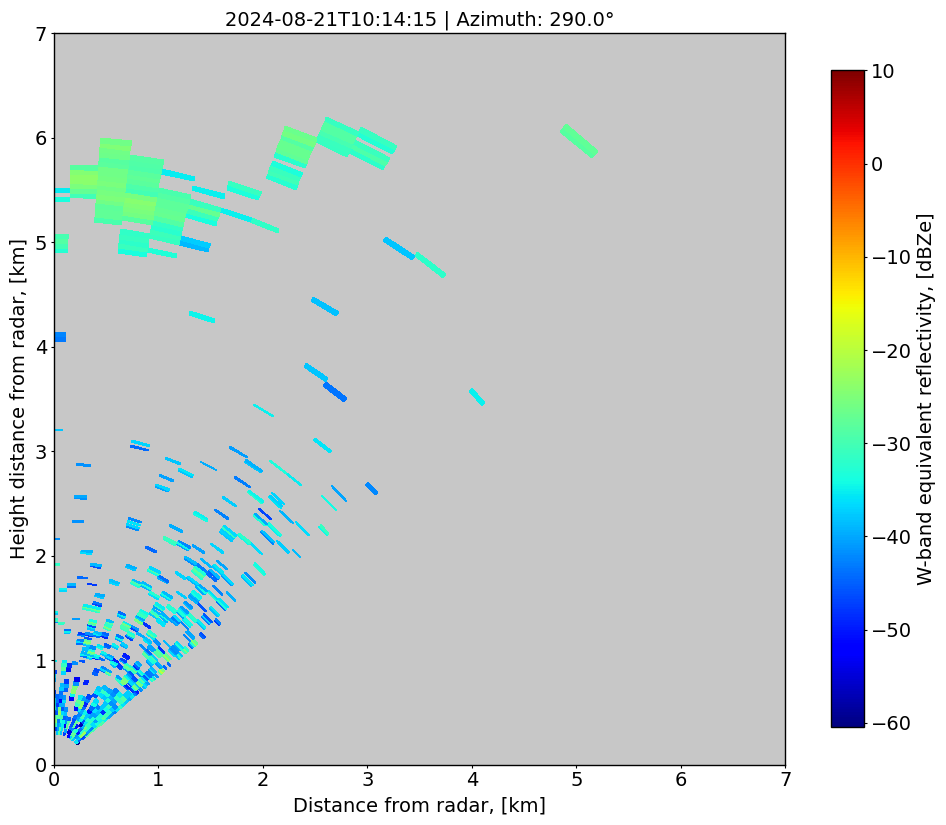

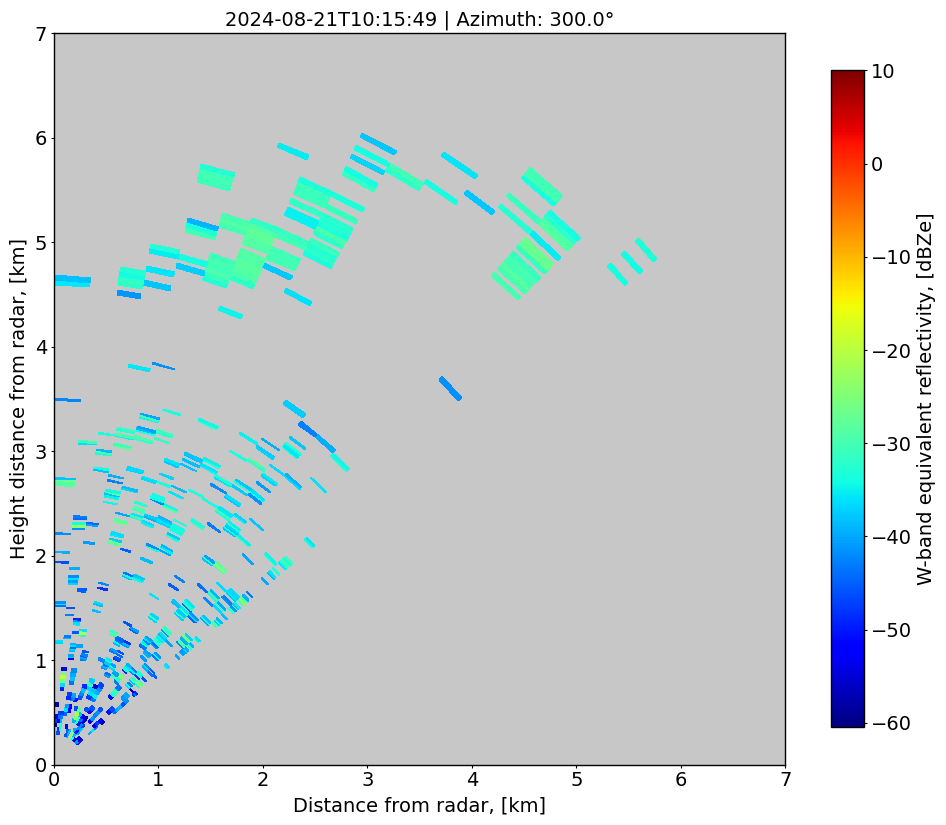

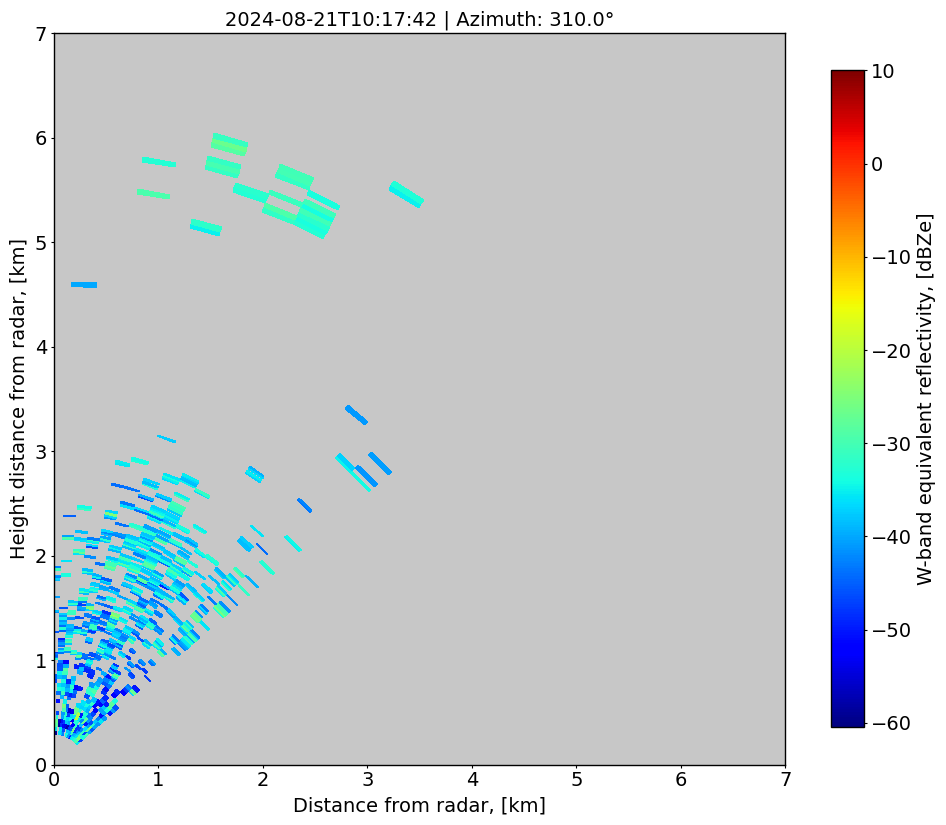

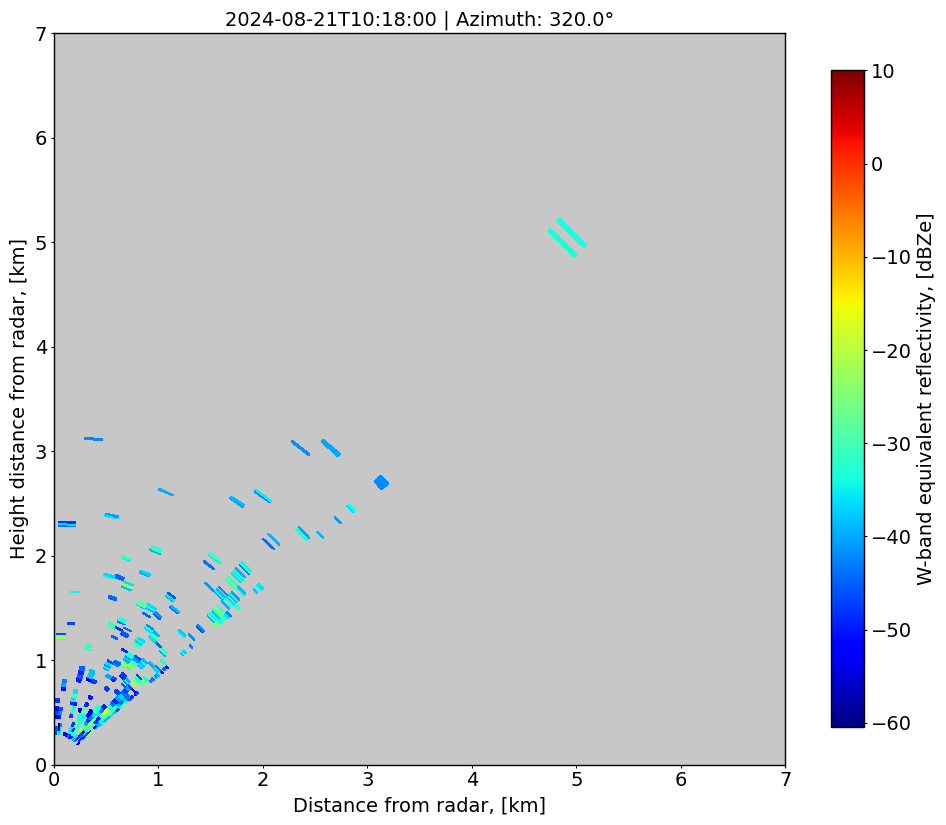

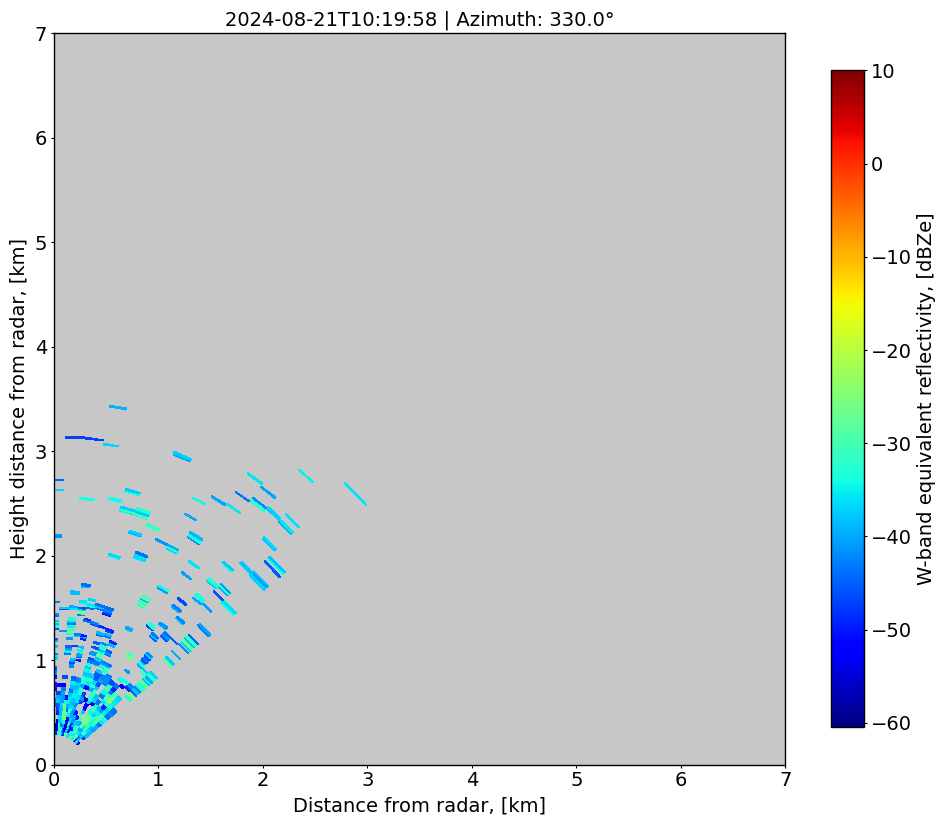

In [4]:
file_number = 1
rpg_radar94 = rpg_radar_list94[file_number]

rpg_radar94.data.lwp.plot.line("-ob", label=rpg_radar94.band)
plt.legend()

plt.figure()
rpg_radar94.data.transmitter_power.plot.line("-ob", label=rpg_radar94.band)
plt.legend()

plt.figure()
rpg_radar94.data.elevation.plot.line("-ok")



for r in rpg_radar_list94:
    figs, filepath = r.plot_rhi(
        variable=[
            "dBZe",
        ],
        vmin = -55,
        vmax = 10,
        savefig=False,
        **{"cmap":"jet", 
        "xlim":[0, 7], 
        "ylim":[0, 7]}
    )

# for r in rpg_radar_list94:
#     figs, filepath = r.plot_rhi(
#         variable=[
#             "zdr",
#         ],
#         vmin = -2,
#         vmax = 2,
#         savefig=False,
#         **{"cmap":"jet", 
#         "xlim":[0, 7], 
#         "ylim":[0, 7]}
#     )

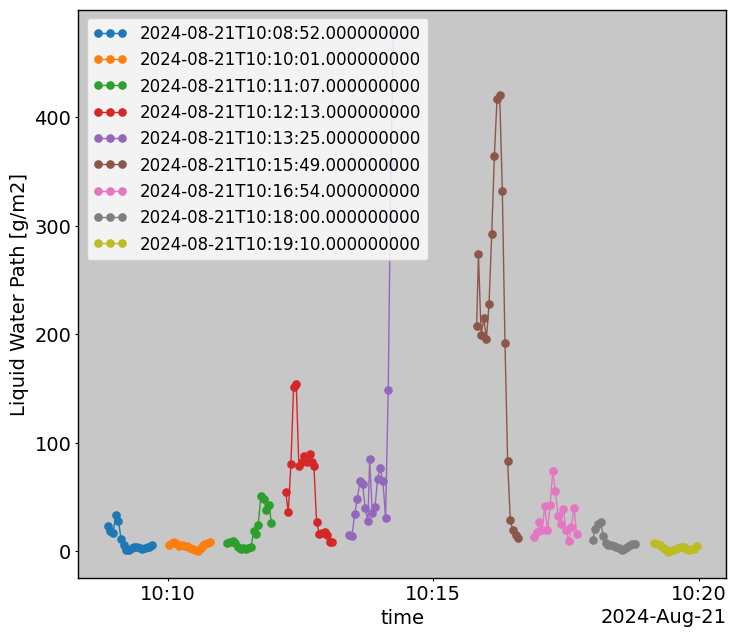

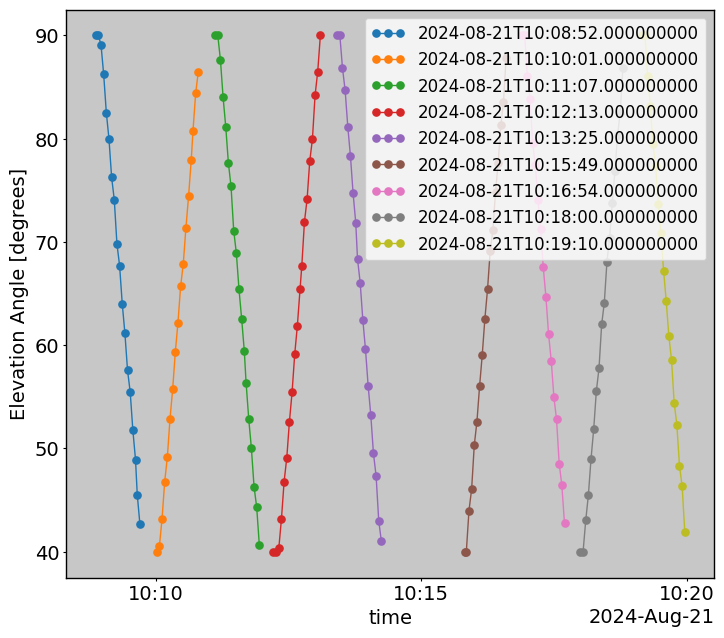

In [5]:
fig = plt.figure(figsize=(8, 8))
for i in range(len(rpg_radar_list94)):
    rpg_radar_list94[i].data.lwp.plot.line("-o", label=rpg_radar_list94[i].data.time.values[0])

plt.legend()

fig = plt.figure(figsize=(8, 8))
for i in range(len(rpg_radar_list94)):
    rpg_radar_list94[i].data.elevation.plot.line("-o", label=rpg_radar_list94[i].data.time.values[0])

plt.legend()

/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates

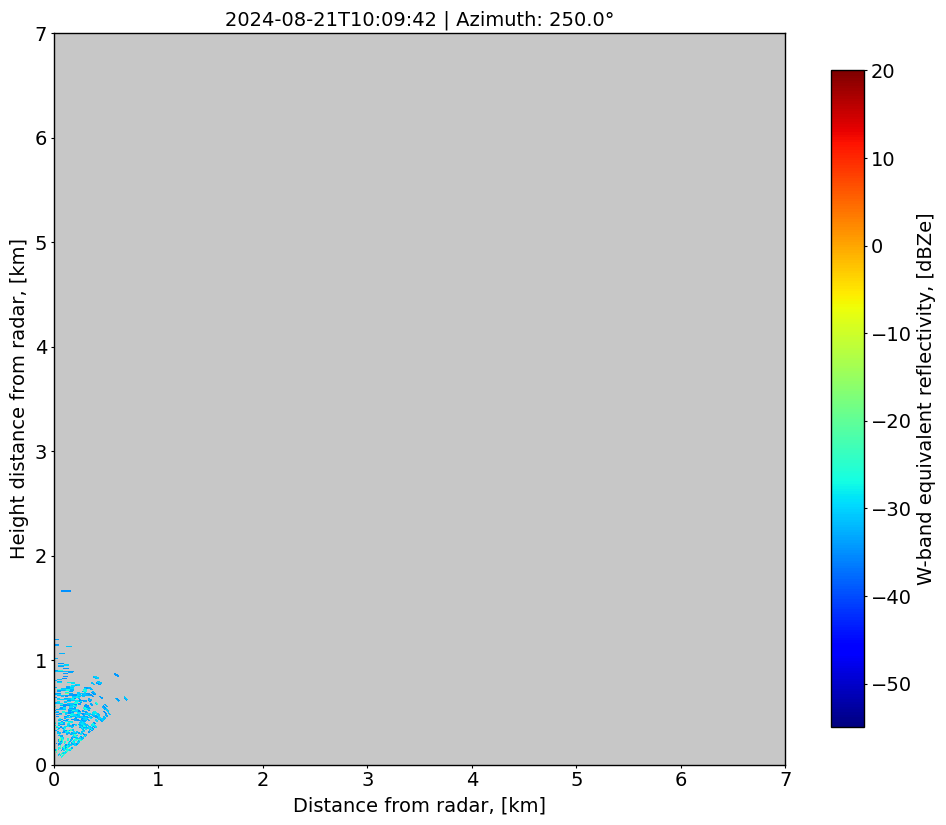

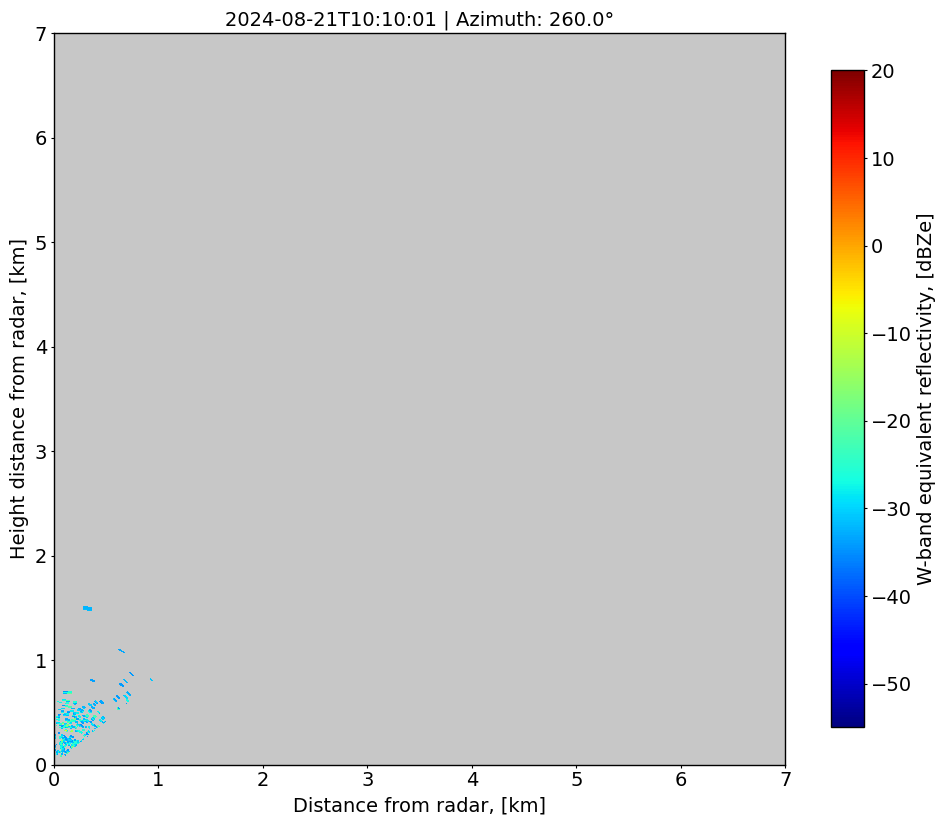

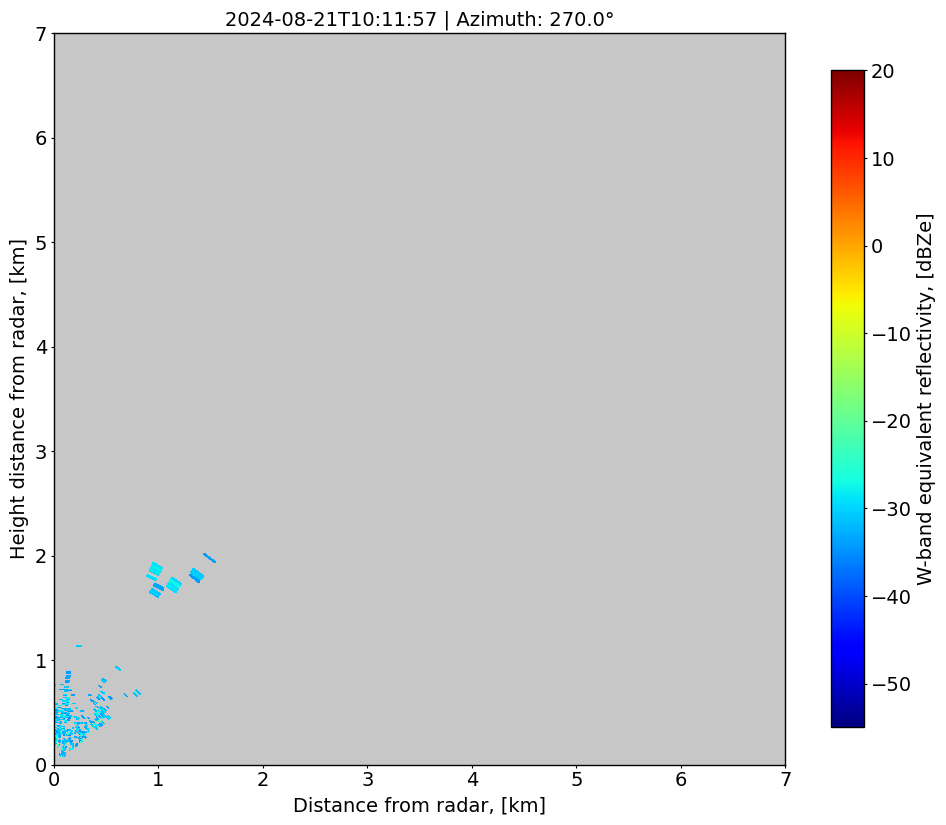

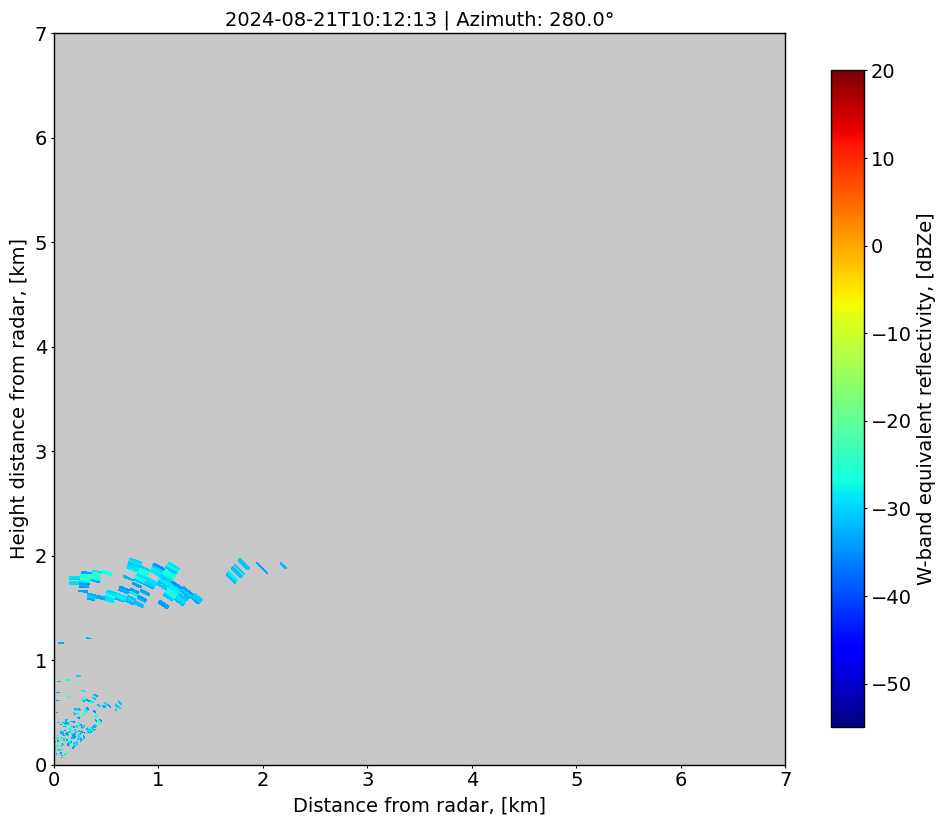

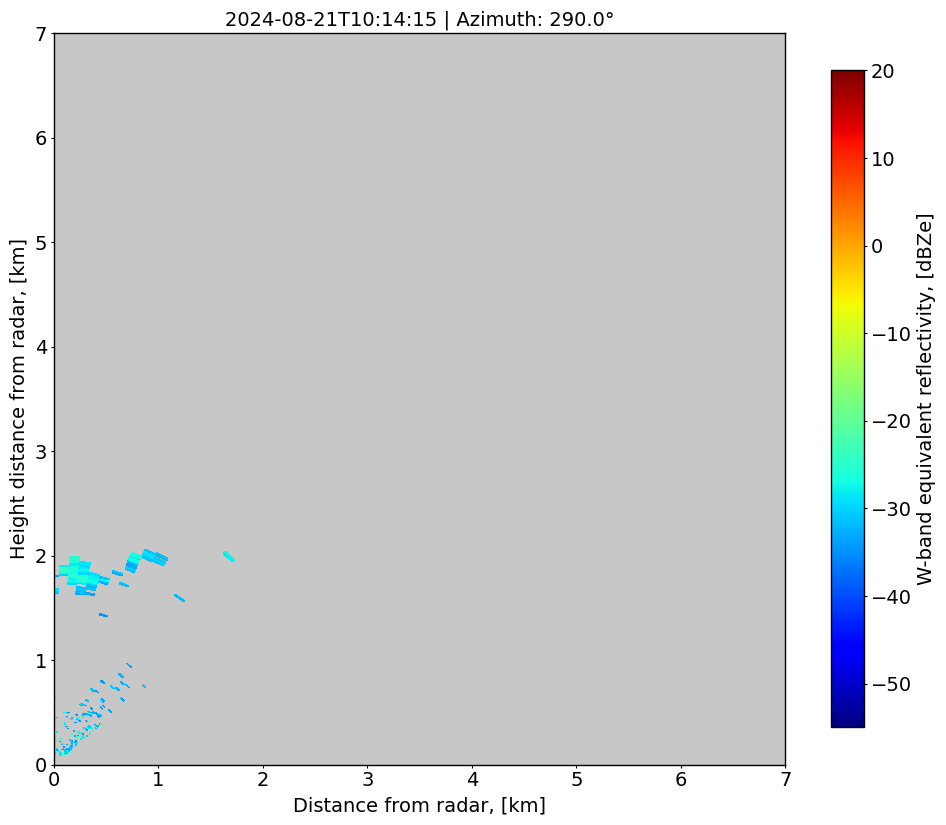

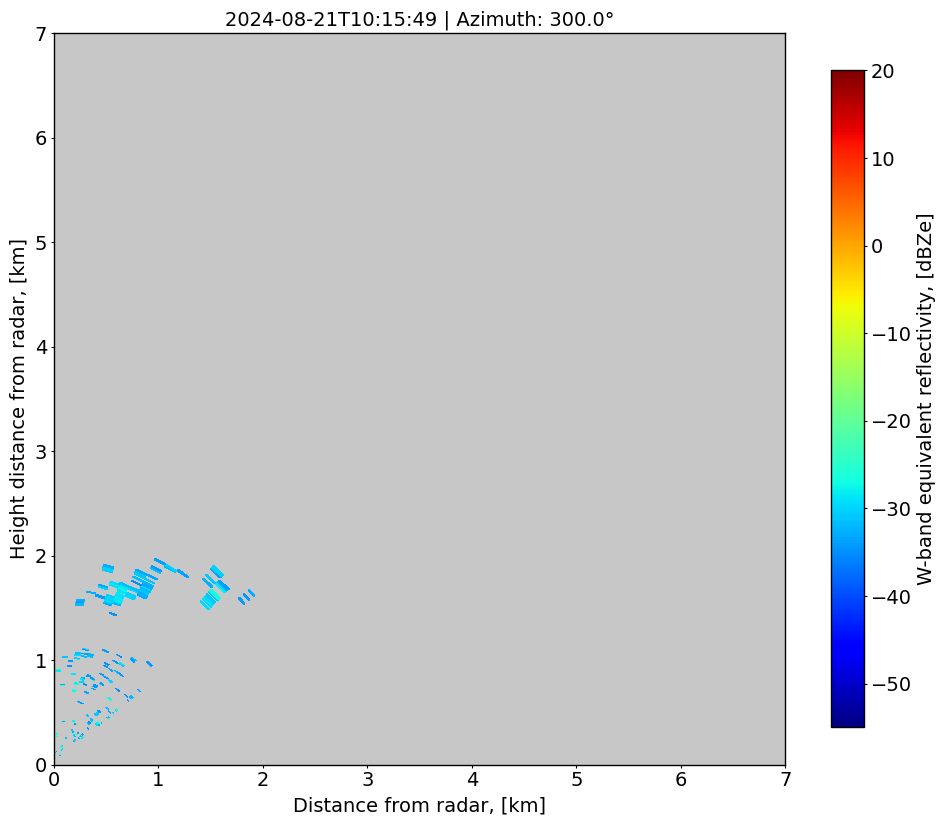

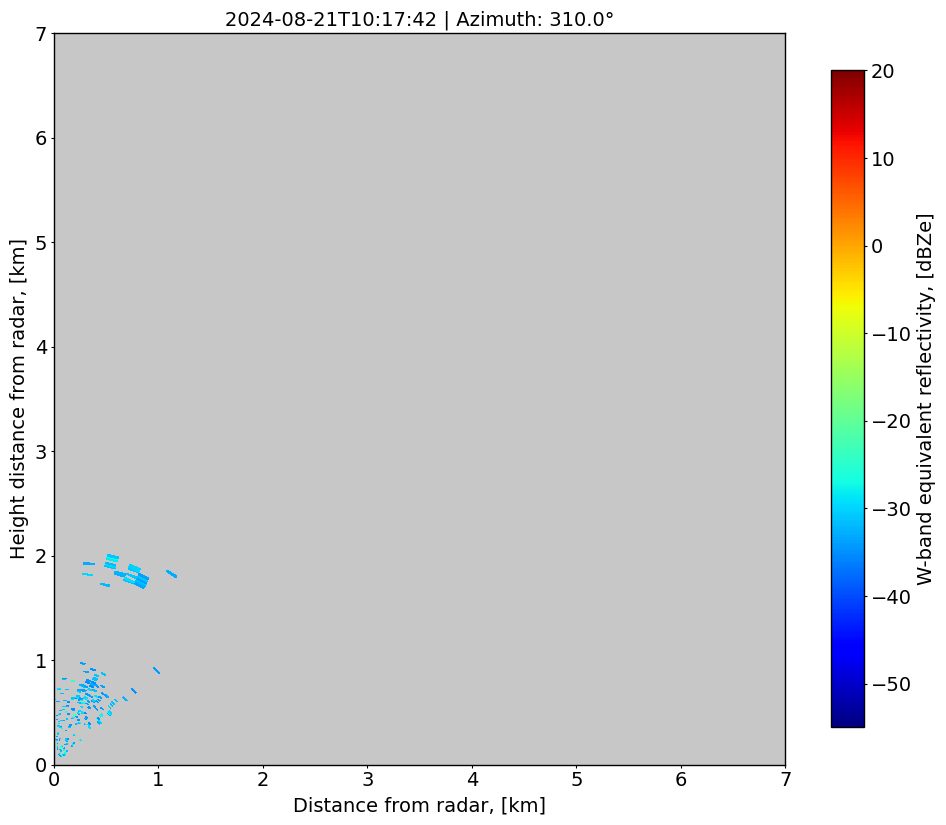

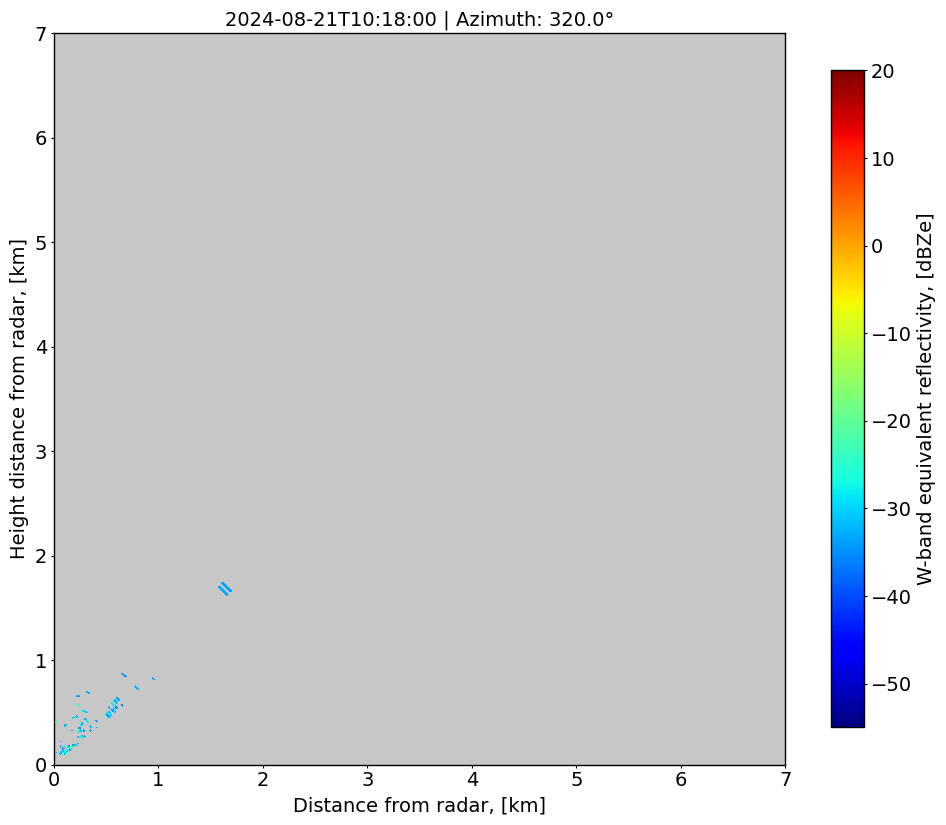

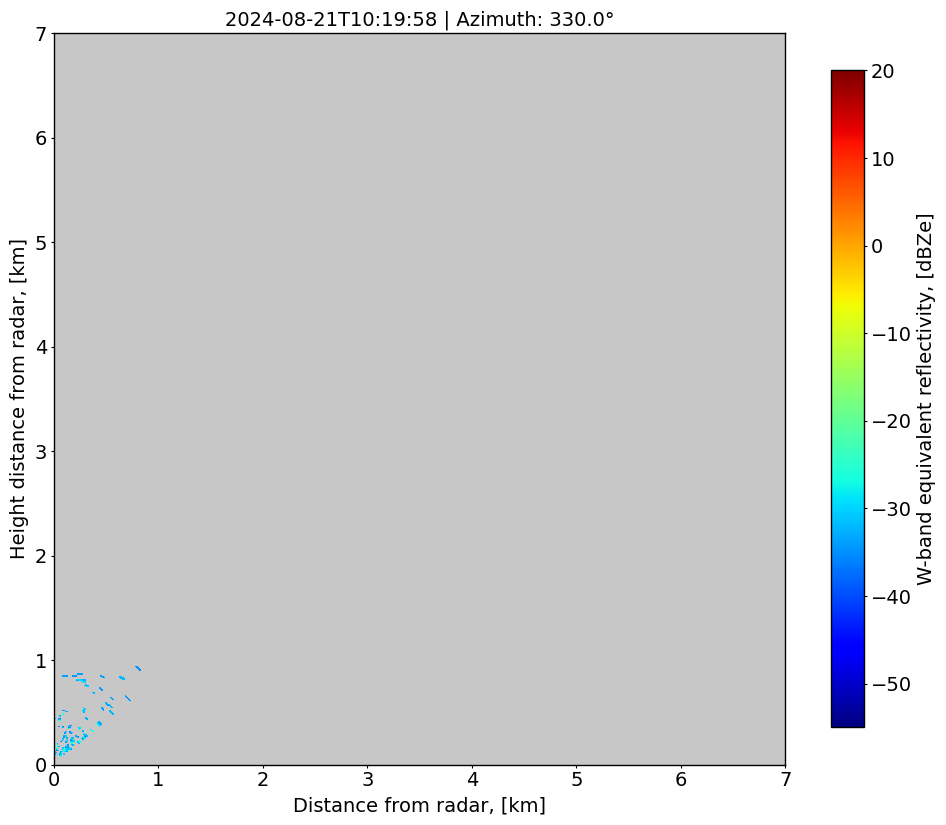

In [7]:
threshold_dbze = -35
for r in rpg_radar_list94:
    r.data.dBZe.values[r.data.dBZe.values < threshold_dbze] = np.nan
    r.data.Ze.values[r.data.dBZe.values < threshold_dbze] = np.nan
    # r.data["range"] = r.data.range.values/3
    # put nan on data below 4000 m
    # r.data.dBZe.values[r.data.range > 4000] = np.nan
    # r.data.Ze.values[r.data.Ze.range > 4000] = np.nan
    figs, filepath = r.plot_rhi(
        variable=[
            "dBZe",
        ],
        savefig=False,
        **{"cmap":"jet", 
        "xlim":[0, 7], 
        "ylim":[0, 7]}
    )

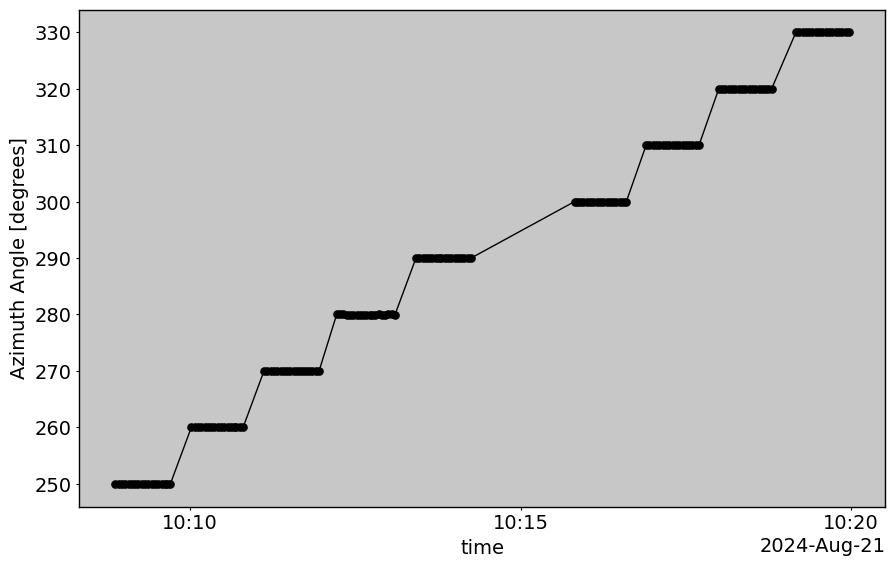

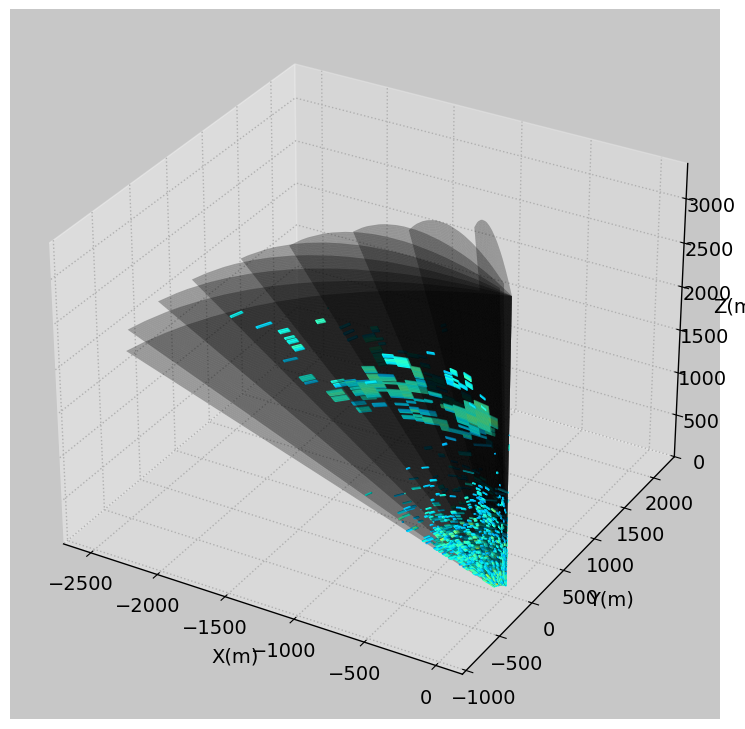

In [18]:
# Concatenating radar data from joydurado94 and joydurado35
print("Concatenating radar data...")
figure_scans = Path(r"/Users/matheussilva/Documents/data-joydurado/figures/w-band/D21")


for i in range(len(rpg_radar_list94)):
    if i == 0:
        radar94data = rpg_radar_list94[i].data
        # radar35data = rpg_radar_list35[i].data
    else:
        radar94data = xr.concat([radar94data, rpg_radar_list94[i].data], dim='time').sortby('time')
        # radar35data = xr.concat([radar35data, rpg_radar_list35[i].data], dim='time').sortby('time')

# change the range of the radar 
radar94data.azimuth.plot.line("-ok", size=7)
plt.show()

# 2) Read the RPG LV1 data plot the RHI measueremts
norm = Normalize(vmin=-55, vmax=10)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
# get only the elements of the lis in indices_to_keep
filtered_rpg_radar = rpg_radar_list94
# filtered_rpg_radar = [rpg_radar_list94[i] for i in indices_to_keep]
rhi_datasets = []
for i, radar in enumerate(filtered_rpg_radar):
    xrradar = radar.data
    rhi_datasets.append(xrradar)
    # change the range of the radar
    xrradar['range'] = xrradar['range']
    r, theta, phi, x, y, z = spherical_to_cartesian(xrradar['range'], xrradar['azimuth'], xrradar['elevation'])
    values = xrradar['dBZe'].values.T
    # put nans on data below 2 km 

    # cartesian_coords = np.array([x.ravel(), y.ravel(), z.ravel()]).T
    # transposed_values = xrradar['dBZe'].values.T.ravel()
    # mask = np.isnan(values)
    # x = x[~mask]
    # y = y[~mask]
    # z = z[~mask]
    # values = values[~mask]

    # rho = np.sqrt(x**2 + y**2)
    colors = plt.get_cmap('jet')(norm(values))
    pcm = ax.plot_surface(x, y, z, facecolors=colors,
                          rstride=1,
                          cstride=1,
                          alpha=0.3,
                          cmap='jet',
                          vmin=-40, vmax=10, shade=False)
ax.set_xlabel('X(m)')
ax.set_ylabel('Y(m)')
ax.set_zlabel('Z(m)')
# set limits of each axis
# ax.set_title('RHI Scanning Measurement')
# plt.colorbar(pcm, ax=ax, label='dBZ', norm=norm)
fig.savefig(figure_scans / "rhi_scanning_measurement.png")
plt.show()

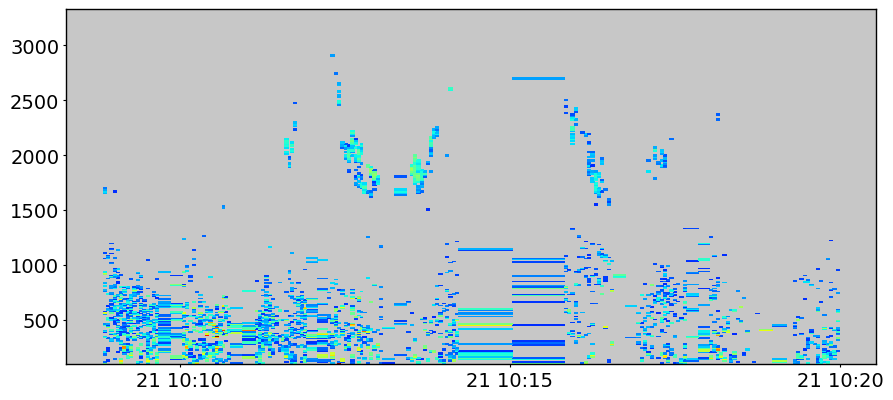

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.pcolor(radar94data.time, radar94data.range, radar94data.dBZe.T, cmap='jet', vmin=-40, vmax=-10)

# 3D reconstruction using joyrad94

### - Convert spherical to cartesian coordinates
### - Do the delaunay triangulation

In [15]:
radar_data.range.values

array([1505.4775, 1520.3833, 1535.2891, 1550.1947, 1565.1005, 1580.0062,
       1594.912 , 1609.8175, 1624.7233, 1639.629 , 1654.5348, 1669.4404,
       1684.3462, 1699.252 , 1714.1576, 1729.0634, 1743.9691, 1758.8749,
       1773.7804, 1788.6862, 1803.5919, 1818.4977, 1833.4033, 1848.3091,
       1863.2148, 1878.1206, 1893.0262, 1907.932 , 1922.8378, 1937.7433,
       1952.649 , 1967.5548, 1982.4606, 1997.3662, 2012.272 , 2027.1777,
       2042.0835, 2056.989 , 2071.8948, 2086.8005, 2101.7063, 2116.612 ,
       2131.5178, 2146.4236, 2161.329 , 2176.2349, 2191.1406, 2206.0464,
       2220.952 , 2235.8577, 2250.7634, 2265.6692, 2280.575 , 2295.4807,
       2310.3865, 2325.2922, 2340.1978, 2355.1035, 2370.0093, 2384.915 ,
       2399.8206, 2414.7263, 2429.632 , 2444.5378, 2459.4436, 2474.3494,
       2489.2551, 2504.1606, 2519.0664, 2533.9722, 2548.878 , 2563.7834,
       2578.6892, 2593.595 , 2608.5007, 2623.4065, 2638.3123, 2653.218 ,
       2668.1235, 2683.0293, 2697.935 , 2712.8408, 

In [11]:
radar_data = radar94data.sel(range=slice(1500, 4000))
rm, thetam, phim, xm, ym, zm = spherical_to_cartesian(radar_data['range'], radar_data['azimuth'], radar_data['elevation'])

cartesian_coords = np.array([xm.ravel(), ym.ravel(), zm.ravel()]).T
# -------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------
# Filetring the reflectivity values
# -------------------------------------------------------------------------------------------
# mask_ze = radar_data['dBZe'].values < -40
# radar_data['dBZe'].values[mask_ze] = np.nan
# radar_data['Ze'].values[mask_ze] = np.nan
transposed_ze = radar_data['dBZe'].values.T.ravel()
# -------------------------------------------------------------------------------------------
# calculating the liquid water content (LWC) inside the cloud
# -------------------------------------------------------------------------------------------
A = np.sqrt(radar_data['Ze'])

# B = np.sqrt(radar_data['Ze']).sum(dim='range')*radar_data['range'].diff(dim='range')

B = np.sqrt(radar_data['Ze']).fillna(0).integrate('range')

cloud_lwc = radar_data['lwp']*A/B # in g/m^3
transposed_lwc = cloud_lwc.values.T.ravel()
# -------------------------------------------------------------------------------------------

# Remove NaN values for the Delaunay triangulation
# Using the lwc to filter data. If lwc is lower than 10 mg/m^3, then put nans in the data
# mask             = np.isnan(transposed_ze)
# transposed_ze[transposed_lwc < 7] = np.nan

mask             = np.isnan(transposed_ze)
cartesian_coords = cartesian_coords[~mask]
values  = transposed_ze[~mask]

values  = transposed_lwc[~mask]

# -------------------------------------------------------------------------------------------
# Delaunay triangulation
# -------------------------------------------------------------------------------------------
tri = Delaunay(cartesian_coords)

### - Interpolate in a regular grid ( Baricentric interpolation)

In [16]:
# -------------------------------------------------------------------------------------------
# Barycentric Interpolation
# -------------------------------------------------------------------------------------------
dgrid = 50
grid_x, grid_y, grid_z = np.meshgrid(np.arange(xm.min(), xm.max(), dgrid),
                                     np.arange(ym.min(), ym.max(), dgrid),
                                     np.arange(zm.min(), zm.max(), dgrid))

grid_cartesian_coords = np.vstack([grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]).T

interp      = LinearNDInterpolator(tri, values)
grid_values = interp(grid_cartesian_coords)

In [22]:
mask                 = np.isnan(grid_values)
cartesian_grid_cloud = grid_cartesian_coords[~mask]
values_cloud         = grid_values[~mask]

mlab.figure(size=(1000, 1000), bgcolor=(0,0,0))
points = mlab.points3d(cartesian_grid_cloud[:, 0]/1e3,
                       cartesian_grid_cloud[:, 1]/1e3,
                       cartesian_grid_cloud[:, 2]/1e3,
                       values_cloud, colormap="jet")
title = r"g/m$^{3}$"
colorbar = mlab.colorbar(points, title=title, orientation='vertical', nb_labels=8)
mlab.axes(xlabel='X', ylabel='Y', zlabel='Z')
# colorbar.scalar_bar.unconstrained_font_size = True  # Allow font size to be adjusted freely
# colorbar.scalar_bar_representation.position = [0.85, 0.15]
# colorbar.scalar_bar_representation.position2 = [0.2, 0.7]
mlab.savefig("../figures/RHI_cloud_reconstruction.png")
mlab.show()

In [95]:
values_cloud.max()

16.604784904722333

In [91]:
values.max()

28.613167

In [72]:
values_cloud.shape[0]*(125000*50e-6)

76537.5

In [63]:
values_cloud.shape[0]**(1/3)*dgrid 

1623.3553379719929

In [23]:
total_water_content = (values_cloud.sum()*dgrid**3) # Tons
total_water_content*1e-6

1012.2596185882563

# Saving quicklooks to figure folder

In [3]:
raw_folder     = "/Users/matheussilva/Documents/data-joydurado/joydurado94/D21/"
product_folder = "/Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/"
figure_folder = Path(r"/Users/matheussilva/Documents/data-joydurado/figures/w-band/D21")

date    = "" # use this to specify a date only if data are inside a folder like this 2024/01/01
qpattern = "*RHI.LV1"

# check if exist the folder raw folder first
if os.path.exists(raw_folder):
    raw_files = os.path.join(raw_folder, date) # folder with raw files
    print("path to raw files: ", raw_files)

    print("path to products files:", product_folder)

    print("make product folder if it does not exist ...")
    # make the folder if it does not exist
    os.makedirs(product_folder, exist_ok=True) 

    # get the list of raw files lv1
    filepaths = glob.glob(os.path.join(raw_files, qpattern))
    
    print("converting files to netcdf if they do not exist ...")
    # check if there are files to process or if they already exist
    if len(filepaths) == 0 or all([os.path.exists(os.path.join(product_folder, f.split("/")[-1]+".nc")) for f in filepaths]):
        print("There are no files to process or they already exist")
    else:
        # converting to raw files to netcdf using rpgpy
        for f in filepaths:
            print("converting file:", f)
            rpg2nc(f, os.path.join(product_folder, f.split("/")[-1]+".nc"))

else:
    print("The raw folder does not exist")

# get filepath of files ended with RHI.LV1.nc
filepaths = glob.glob(os.path.join(product_folder, qpattern+".nc"))

# order the files by date
filepaths = sorted(filepaths)

# check if there are files to process
if len(filepaths) == 0:
    print("There are no files to process")
else:
    print("netcdf files created by rpgpy:")
    for f in filepaths:
        print(f)

    # check if filepaths is a list:
    print("\nreading the file as radar class in gfatpy...")
    if isinstance(filepaths, list):
        radar = rpg(filepaths[0])
    else:
        radar = rpg(filepaths)

rpg_radar_list94 = [rpg(f) for f in filepaths]

path to raw files:  /Users/matheussilva/Documents/data-joydurado/joydurado94/D21/
path to products files: /Users/matheussilva/Documents/data-joydurado/PRODUCTS/joydurado94/D21/
make product folder if it does not exist ...
converting files to netcdf if they do not exist ...
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado94/D21/VITAL_SEC3_240821_101440_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado94/D21/VITAL_SEC2_240821_115625_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado94/D21/VITAL_SEC3_240821_105141_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado94/D21/VITAL_SEC1_240821_113326_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado94/D21/VITAL_SEC2_240821_093623_P08_RHI.LV1
converting file: /Users/matheussilva/Documents/data-joydurado/joydurado94/D21/VITAL_SEC2_240821_102839_P08_RHI.LV1
converting file: /Users/matheussilva

In [14]:
if radar.level == 1 and radar.type == "RHI":
    for r in rpg_radar_list94:
        figs, filepath = r.plot_rhi(
            variable=[
                "dBZe",
            ],
            dpi=400,
            vmin=-50,
            vmax=5,
            savefig=True,
            output_dir=figure_folder,
            **{"cmap":"jet", "xlim":[0, 7], "ylim":[0, 7]},
        )



/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates

In [ ]:
try:
    if radar.level == 1 and radar.type == "RHI":
        for r in rpg_radar_list94:
            figs, filepath = r.plot_rhi(
                variable=[
                    "ldr_slanted",
                ],
                dpi=400,
                vmin=-20,
                vmax=1,
                savefig=True,
                output_dir=figure_folder,
                **{"cmap":"jet", "xlim":[0, 4], "ylim":[0, 4]},
            )
except Exception as e:
    print(e)


/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates

In [85]:
try:
    if radar.level == 1 and radar.type == "RHI":
        for r in rpg_radar_list94:
            figs, filepath = r.plot_rhi(
                variable=[
                    "zdr",
                ],
                dpi=400,
                vmin=-5,
                vmax=10,
                savefig=True,
                output_dir=figure_folder,
                **{"cmap":"jet", "xlim":[0, 4], "ylim":[0, 4]},
            )
except Exception as e:
    print(e)

/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/Users/matheussilva/Library/Caches/pypoetry/virtualenvs/phd-clouds-lT9TNTHZ-py3.10/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:666: UserWarning: The input coordinates

In [ ]:
try:
    if radar.level == 1 and radar.type == "RHI":
        for r in rpg_radar_list94:
            figs, filepath = r.plot_rhi(
                variable=[
                    "differential_phase_shift",
                ],
                dpi=400,
                vmin=-5,
                vmax=5,
                savefig=True,
                output_dir=figure_folder,
                **{"cmap":"jet", "xlim":[0, 4], "ylim":[0, 4]},
            )
except Exception as e:
    print(e)

In [ ]:
try:
    if radar.level == 1 and radar.type == "RHI":
        figs, filepath = radar.plot_rhi(
            variable=[
                "v",
            ],
            dpi=400,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet", "xlim":[0, 4], "ylim":[0, 4]},
        )
except Exception as e:
    print(e)

In [ ]:
try:
    if radar.level == 1 and radar.type == "RHI":
        figs, filepath = radar.plot_rhi(
            variable=[
                "dBZe",
            ],
            dpi=400,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet", "xlim":[0, 4], "ylim":[0, 4]},
        )
except Exception as e:
    print(e)

In [ ]:
# radar.data.zdr.values = 10*np.log( radar.data.zdr ) 
try:
    if radar.level == 1 and radar.type == "RHI":
        figs, filepath = radar.plot_rhi(
            variable=[
                "differential_phase_shift",
            ],
            dpi=400,
            vmin=-10,
            vmax=10,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet", "xlim":[0, 3], "ylim":[0, 3]}
        )
except Exception as e:
    print(e)

In [ ]:
# radar.data.zdr.values = 10*np.log( radar.data.zdr ) 
try:
    if radar.level == 1 and radar.type == "RHI":
        figs, filepath = radar.plot_rhi(
            variable=[
                "width",
            ],
            dpi=400,
            vmin=0.,
            vmax=5,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet", "xlim":[0, 4], "ylim":[0, 4]}
        )
except Exception as e:
    print(e)